# Introduction

En el contexto de la f1, cada factor influye. Este proyecto nace de una tendencia de predecir modelos de quien gana campeonatos de F1 pero como cientifico de datos certificado de IBM creo que las variables de clima afectan no solo al piloto sino al auto, como una maquina de ingenieria una variacion podria cambiar el rendimiento de la f1 para bien o para mal.

🎯 Hipótesis inicial
Mi hipotesis es que las condiciones climáticas (temperatura, lluvia, humedad, etc.) son un factor significativo que influye en los resultados de las carreras, afectando el agarre de los neumáticos, la estrategia de equipo y el rendimiento del monoplaza.

esta prueba de conceptos se hara con datos estaticos y busca evaluar la hipotesis antes de impulsarse en un proyecto mayor estudiando primero viabilidad y conceptos.

# Data set
| Gran Premio               | Ciudad del Circuito     | Ciudad del Dataset     | Distancia Aprox. |
|--------------------------|--------------------------|-------------------------|------------------|
| GP de Emilia Romagna     | Imola, Italia            | Forlì, Italia           | ~40 km           |
| GP de Arabia Saudita     | Jeddah                   | Jeddah                  | ~10 km           |
| GP de Abu Dhabi          | Abu Dhabi                | Abu Dhabi               | ~10 km           |
| GP de China              | Shanghái                 | Shanghái                | ~30 km           |
| GP de Las Vegas          | Las Vegas, NV            | Las Vegas, NV           | ~5 km            |
| GP de Brasil             | São Paulo                | São Paulo               | ~20 km           |
| GP de México             | Ciudad de México         | Ciudad de México        | ~15 km           |
| GP de EE. UU. (COTA)     | Austin, TX               | Austin, TX              | ~25 km           |
| GP de Qatar              | Lusail                   | Doha                    | ~20 km           |
| GP de Japón              | Suzuka                   | Nagoya                  | ~60 km           |
| GP de Italia             | Monza, Italia            | Monza, Italia           | ~5 km            |
| GP de Países Bajos       | Zandvoort                | Zandvoort               | ~5 km            |
| GP de Hungría            | Mogyoród                 | Budapest                | ~20 km           |
| GP de Gran Bretaña       | Silverstone              | Northampton             | ~20 km           |
| GP de Austria            | Spielberg                | Knittelfeld             | ~15 km           |
| GP de Canadá             | Montreal                 | Montreal                | ~10 km           |
| GP de España             | Barcelona                | Barcelona               | ~10 km           |
| GP de Mónaco             | Mónaco                   | Mónaco                  | ~5 km            |
| GP de Azerbaiyán         | Bakú                     | Bakú                    | ~5 km            |
| GP de Australia          | Melbourne                | Melbourne               | ~10 km           |
| GP de Miami              | Miami, FL                | Miami, FL               | ~10 km           |
| GP de Baréin             | Sakhir                   | Manama                  | ~25 km           |
| GP de Singapur           | Singapur                 | Singapur                | ~5 km            |
| GP de Bélgica            | Spa-Francorchamps        | Durbuy                  | ~30 km           |

⚠️ Nota sobre la precisión de los datos
Para este análisis exploratorio inicial, se han utilizado datasets de ciudades cercanas en aquellos casos donde los datos exactos del circuito no estaban fácilmente disponibles. Esta aproximación sirve para probar la viabilidad de nuestra hipótesis sobre la influencia del clima en la carrera. La siguiente fase del proyecto buscará datos meteorológicos más precisos (NOAA, METAR) para refinar el modelo predictivo.

# Importacion de datos

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import glob as glob


# F1 Tratamiento de datos

In [ ]:
df_f1_season_2019 = pd.read_csv('/content/sample_data/formula1_2019season_raceResults.csv')
display(df_f1_season_2019.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap
0,Australia,1,77,Valtteri Bottas,Mercedes,2,58,1:25:27.325,26,Yes
1,Australia,2,44,Lewis Hamilton,Mercedes,1,58,+20.886,18,No
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4,58,+22.520,15,No
3,Australia,4,5,Sebastian Vettel,Ferrari,3,58,+57.109,12,No
4,Australia,5,16,Charles Leclerc,Ferrari,5,58,+58.230,10,No


Calendar

In [ ]:
df_calendar_2019 = pd.read_excel('/content/sample_data/2019_calendar.xlsx')
display(df_calendar_2019.head())

,Track,Date
0,Australia,2019-03-17
1,Bahrain,2019-03-31
2,China,2019-04-14
3,Azerbaijan,2019-04-28
4,Spain,2019-05-12


In [ ]:
df_f1_con_fechas_2019 = pd.merge(
    df_f1_season_2019,  # El DataFrame de resultados (izquierda)
    df_calendar_2019,   # El DataFrame del calendario (derecha)
    on='Track',         # La columna común que se usa para la unión
    how='left'          # Usamos 'left' para mantener todas las filas de tus resultados
)

display(df_f1_con_fechas_2019.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date
0,Australia,1,77,Valtteri Bottas,Mercedes,2,58,1:25:27.325,26,Yes,2019-03-17
1,Australia,2,44,Lewis Hamilton,Mercedes,1,58,+20.886,18,No,2019-03-17
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4,58,+22.520,15,No,2019-03-17
3,Australia,4,5,Sebastian Vettel,Ferrari,3,58,+57.109,12,No,2019-03-17
4,Australia,5,16,Charles Leclerc,Ferrari,5,58,+58.230,10,No,2019-03-17


# 2020 season

In [ ]:
df_f1_season_2020 = pd.read_csv('/content/sample_data/formula1_2020season_raceResults.csv')
display(df_f1_season_2020.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap
0,Austria,1,77,Valtteri Bottas,Mercedes,1,71,1:30:55.739,25,No
1,Austria,2,16,Charles Leclerc,Ferrari,7,71,+2.700,18,No
2,Austria,3,4,Lando Norris,McLaren Renault,3,71,+5.491,16,Yes
3,Austria,4,44,Lewis Hamilton,Mercedes,5,71,+5.689,12,No
4,Austria,5,55,Carlos Sainz,McLaren Renault,8,71,+8.903,10,No


calendar

In [ ]:
df_calendar_2020 = pd.read_excel('/content/sample_data/2020_calendar.xlsx')
display(df_calendar_2020.head())

,Track,Date
0,Austria,2020-07-05
1,Styria,2020-07-12
2,Hungary,2020-07-19
3,Great Britain,2020-08-02
4,70th Anniversary,2020-08-09


In [ ]:
df_f1_con_fechas_2020 = pd.merge(
    df_f1_season_2020,
    df_calendar_2020,
    on='Track',
    how='left'
)
display(df_f1_con_fechas_2020.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date
0,Austria,1,77,Valtteri Bottas,Mercedes,1,71,1:30:55.739,25,No,2020-07-05
1,Austria,2,16,Charles Leclerc,Ferrari,7,71,+2.700,18,No,2020-07-05
2,Austria,3,4,Lando Norris,McLaren Renault,3,71,+5.491,16,Yes,2020-07-05
3,Austria,4,44,Lewis Hamilton,Mercedes,5,71,+5.689,12,No,2020-07-05
4,Austria,5,55,Carlos Sainz,McLaren Renault,8,71,+8.903,10,No,2020-07-05


In [ ]:
df_f1_con_fechas_2020.to_csv('df_f1_con_fechas_2020.csv', index=False)

In [ ]:
df_f1_con_fechas_2019.to_csv('df_f1_con_fechas_2019.csv', index=False)

# 2021 season

In [ ]:
df_f1_season_2021 = pd.read_csv('/content/sample_data/formula1_2021season_raceResults.csv')
display(df_f1_season_2021.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap
0,Bahrain,1,44,Lewis Hamilton,Mercedes,2.0,56,1:32:03.897,25.0,No,1:34.015
1,Bahrain,2,33,Max Verstappen,Red Bull Racing Honda,1.0,56,+0.745,18.0,No,1:33.228
2,Bahrain,3,77,Valtteri Bottas,Mercedes,3.0,56,+37.383,16.0,Yes,1:32.090
3,Bahrain,4,4,Lando Norris,McLaren Mercedes,7.0,56,+46.466,12.0,No,1:34.396
4,Bahrain,5,11,Sergio Perez,Red Bull Racing Honda,11.0,56,+52.047,10.0,No,1:33.970


calendar

In [ ]:
df_calendar_2021 = pd.read_excel('/content/sample_data/2021_calendar.xlsx')
display(df_calendar_2021.head())

,Track,Date
0,Bahrain,2021-03-28
1,Emilia Romagna,2021-04-18
2,Portugal,2021-05-02
3,Spain,2021-05-09
4,Monaco,2021-05-23


In [ ]:
df_f1_con_fechas_2021 = pd.merge(
    df_f1_season_2021,
    df_calendar_2021,
    on='Track',
    how='left'
)
display(df_f1_con_fechas_2021.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,Date
0,Bahrain,1,44,Lewis Hamilton,Mercedes,2.0,56,1:32:03.897,25.0,No,1:34.015,2021-03-28
1,Bahrain,2,33,Max Verstappen,Red Bull Racing Honda,1.0,56,+0.745,18.0,No,1:33.228,2021-03-28
2,Bahrain,3,77,Valtteri Bottas,Mercedes,3.0,56,+37.383,16.0,Yes,1:32.090,2021-03-28
3,Bahrain,4,4,Lando Norris,McLaren Mercedes,7.0,56,+46.466,12.0,No,1:34.396,2021-03-28
4,Bahrain,5,11,Sergio Perez,Red Bull Racing Honda,11.0,56,+52.047,10.0,No,1:33.970,2021-03-28


In [ ]:
df_f1_con_fechas_2021.to_csv('df_f1_con_fechas_2021.csv', index=False)

#2022 season


In [ ]:
df_f1_season_2022 = pd.read_csv('/content/sample_data/Formula1_2022season_raceResults.csv')
display(df_f1_season_2022.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap
0,Bahrain,1,16,Charles Leclerc,Ferrari,1,57,1:37:33.584,26,Yes,1:34.570
1,Bahrain,2,55,Carlos Sainz,Ferrari,3,57,+5.598,18,No,1:35.740
2,Bahrain,3,44,Lewis Hamilton,Mercedes,5,57,+9.675,15,No,1:36.228
3,Bahrain,4,63,George Russell,Mercedes,9,57,+11.211,12,No,1:36.302
4,Bahrain,5,20,Kevin Magnussen,Haas Ferrari,7,57,+14.754,10,No,1:36.623


Calendar

In [ ]:
df_calendar_2022 = pd.read_excel('/content/sample_data/2022_calendar.xlsx')
display(df_calendar_2022.head())

,Track,Date
0,Bahrain,2022-03-20
1,Saudi Arabia,2022-03-27
2,Australia,2022-04-09
3,Emilia Romagna,2022-04-24
4,Miami,2022-05-08


In [ ]:
df_f1_con_fechas_2022 = pd.merge(
    df_f1_season_2022,
    df_calendar_2022,
    on='Track',
    how='left'
)
display(df_f1_con_fechas_2022.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,Date
0,Bahrain,1,16,Charles Leclerc,Ferrari,1,57,1:37:33.584,26,Yes,1:34.570,2022-03-20
1,Bahrain,2,55,Carlos Sainz,Ferrari,3,57,+5.598,18,No,1:35.740,2022-03-20
2,Bahrain,3,44,Lewis Hamilton,Mercedes,5,57,+9.675,15,No,1:36.228,2022-03-20
3,Bahrain,4,63,George Russell,Mercedes,9,57,+11.211,12,No,1:36.302,2022-03-20
4,Bahrain,5,20,Kevin Magnussen,Haas Ferrari,7,57,+14.754,10,No,1:36.623,2022-03-20


In [ ]:
df_f1_con_fechas_2022.to_csv('df_f1_con_fechas_2022.csv', index=False)

# season 2023

In [ ]:
df_season_2023 = pd.read_csv('/content/sample_data/Formula1_2023season_raceResults.csv')
display(df_season_2023.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:33:56.736,25,No,1:36.236
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,2,57,+11.987,18,No,1:36.344
2,Bahrain,3,14,Fernando Alonso,Aston Martin Aramco Mercedes,5,57,+38.637,15,No,1:36.156
3,Bahrain,4,55,Carlos Sainz,Ferrari,4,57,+48.052,12,No,1:37.130
4,Bahrain,5,44,Lewis Hamilton,Mercedes,7,57,+50.977,10,No,1:36.546


calendar

In [ ]:
df_calendar_2023 = pd.read_excel('/content/sample_data/2023_calendar.xlsx')
display(df_calendar_2023.head())

,Track,Date
0,Bahrain,2023-03-05
1,Saudi Arabia,2023-05-19
2,Australia,2023-04-01
3,Azerbaijan,2023-04-30
4,Miami,2023-05-07


In [ ]:
df_f1_con_fechas_2023 = pd.merge(
    df_season_2023,
    df_calendar_2023,
    on='Track',
    how='left'
)
display(df_f1_con_fechas_2023.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time,Date
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:33:56.736,25,No,1:36.236,2023-03-05
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,2,57,+11.987,18,No,1:36.344,2023-03-05
2,Bahrain,3,14,Fernando Alonso,Aston Martin Aramco Mercedes,5,57,+38.637,15,No,1:36.156,2023-03-05
3,Bahrain,4,55,Carlos Sainz,Ferrari,4,57,+48.052,12,No,1:37.130,2023-03-05
4,Bahrain,5,44,Lewis Hamilton,Mercedes,7,57,+50.977,10,No,1:36.546,2023-03-05


In [ ]:
df_f1_con_fechas_2023.to_csv('df_f1_con_fechas_2023.csv', index=False)

# 2024 season

In [ ]:
df_season_2024 = pd.read_csv('/content/sample_data/Formula1_2024season_raceResults.csv')
display(df_season_2024.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:31:44.742,26,Yes,1:32.608
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,5,57,+22.457,18,No,1:34.364
2,Bahrain,3,55,Carlos Sainz,Ferrari,4,57,+25.110,15,No,1:34.507
3,Bahrain,4,16,Charles Leclerc,Ferrari,2,57,+39.669,12,No,1:34.090
4,Bahrain,5,63,George Russell,Mercedes,3,57,+46.788,10,No,1:35.065


calendar


In [ ]:
df_calendar_2024 = pd.read_excel('/content/sample_data/2024_calendar.xlsx')
display(df_calendar_2024.head())

,Track,Date
0,Bahrain,2024-03-02
1,Saudi Arabia,2024-03-09
2,Australia,2024-03-23
3,Japan,2024-04-06
4,China,2024-04-21


In [ ]:
df_f1_con_fechas_2024 = pd.merge(
    df_season_2024,
    df_calendar_2024,
    on='Track',
    how='left'
)
display(df_f1_con_fechas_2024.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time,Date
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:31:44.742,26,Yes,1:32.608,2024-03-02
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,5,57,+22.457,18,No,1:34.364,2024-03-02
2,Bahrain,3,55,Carlos Sainz,Ferrari,4,57,+25.110,15,No,1:34.507,2024-03-02
3,Bahrain,4,16,Charles Leclerc,Ferrari,2,57,+39.669,12,No,1:34.090,2024-03-02
4,Bahrain,5,63,George Russell,Mercedes,3,57,+46.788,10,No,1:35.065,2024-03-02


In [ ]:
df_f1_con_fechas_2024.to_csv('df_f1_con_fechas_2024.csv', index=False)

In [ ]:
df_season_2019_column = df_f1_con_fechas_2019.copy()
display(df_season_2019_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date
0,Australia,1,77,Valtteri Bottas,Mercedes,2,58,1:25:27.325,26,Yes,2019-03-17
1,Australia,2,44,Lewis Hamilton,Mercedes,1,58,+20.886,18,No,2019-03-17
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4,58,+22.520,15,No,2019-03-17
3,Australia,4,5,Sebastian Vettel,Ferrari,3,58,+57.109,12,No,2019-03-17
4,Australia,5,16,Charles Leclerc,Ferrari,5,58,+58.230,10,No,2019-03-17


In [ ]:
# Para el dataset de 2019
df_season_2019_column['season'] = 2019
display(df_season_2019_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date,season
0,Australia,1,77,Valtteri Bottas,Mercedes,2,58,1:25:27.325,26,Yes,2019-03-17,2019
1,Australia,2,44,Lewis Hamilton,Mercedes,1,58,+20.886,18,No,2019-03-17,2019
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4,58,+22.520,15,No,2019-03-17,2019
3,Australia,4,5,Sebastian Vettel,Ferrari,3,58,+57.109,12,No,2019-03-17,2019
4,Australia,5,16,Charles Leclerc,Ferrari,5,58,+58.230,10,No,2019-03-17,2019


In [ ]:
df_season_2020_column = df_f1_con_fechas_2020.copy()
display(df_season_2020_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date
0,Austria,1,77,Valtteri Bottas,Mercedes,1,71,1:30:55.739,25,No,2020-07-05
1,Austria,2,16,Charles Leclerc,Ferrari,7,71,+2.700,18,No,2020-07-05
2,Austria,3,4,Lando Norris,McLaren Renault,3,71,+5.491,16,Yes,2020-07-05
3,Austria,4,44,Lewis Hamilton,Mercedes,5,71,+5.689,12,No,2020-07-05
4,Austria,5,55,Carlos Sainz,McLaren Renault,8,71,+8.903,10,No,2020-07-05


In [ ]:
# Para el dataset de 2019
df_season_2020_column['season'] = 2020
display(df_season_2020_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date,season
0,Austria,1,77,Valtteri Bottas,Mercedes,1,71,1:30:55.739,25,No,2020-07-05,2020
1,Austria,2,16,Charles Leclerc,Ferrari,7,71,+2.700,18,No,2020-07-05,2020
2,Austria,3,4,Lando Norris,McLaren Renault,3,71,+5.491,16,Yes,2020-07-05,2020
3,Austria,4,44,Lewis Hamilton,Mercedes,5,71,+5.689,12,No,2020-07-05,2020
4,Austria,5,55,Carlos Sainz,McLaren Renault,8,71,+8.903,10,No,2020-07-05,2020


In [ ]:
df_season_2021_column = df_f1_con_fechas_2021.copy()
df_season_2021_column['season'] = 2021
display(df_season_2021_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,Date,season
0,Bahrain,1,44,Lewis Hamilton,Mercedes,2.0,56,1:32:03.897,25.0,No,1:34.015,2021-03-28,2021
1,Bahrain,2,33,Max Verstappen,Red Bull Racing Honda,1.0,56,+0.745,18.0,No,1:33.228,2021-03-28,2021
2,Bahrain,3,77,Valtteri Bottas,Mercedes,3.0,56,+37.383,16.0,Yes,1:32.090,2021-03-28,2021
3,Bahrain,4,4,Lando Norris,McLaren Mercedes,7.0,56,+46.466,12.0,No,1:34.396,2021-03-28,2021
4,Bahrain,5,11,Sergio Perez,Red Bull Racing Honda,11.0,56,+52.047,10.0,No,1:33.970,2021-03-28,2021


In [ ]:
df_season_2022_column = df_f1_con_fechas_2022.copy()
df_season_2022_column['season'] = 2022
display(df_season_2022_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,Date,season
0,Bahrain,1,16,Charles Leclerc,Ferrari,1,57,1:37:33.584,26,Yes,1:34.570,2022-03-20,2022
1,Bahrain,2,55,Carlos Sainz,Ferrari,3,57,+5.598,18,No,1:35.740,2022-03-20,2022
2,Bahrain,3,44,Lewis Hamilton,Mercedes,5,57,+9.675,15,No,1:36.228,2022-03-20,2022
3,Bahrain,4,63,George Russell,Mercedes,9,57,+11.211,12,No,1:36.302,2022-03-20,2022
4,Bahrain,5,20,Kevin Magnussen,Haas Ferrari,7,57,+14.754,10,No,1:36.623,2022-03-20,2022


In [ ]:
df_season_2023_column = df_f1_con_fechas_2023.copy()
df_season_2023_column['season'] = 2023
display(df_season_2023_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time,Date,season
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:33:56.736,25,No,1:36.236,2023-03-05,2023
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,2,57,+11.987,18,No,1:36.344,2023-03-05,2023
2,Bahrain,3,14,Fernando Alonso,Aston Martin Aramco Mercedes,5,57,+38.637,15,No,1:36.156,2023-03-05,2023
3,Bahrain,4,55,Carlos Sainz,Ferrari,4,57,+48.052,12,No,1:37.130,2023-03-05,2023
4,Bahrain,5,44,Lewis Hamilton,Mercedes,7,57,+50.977,10,No,1:36.546,2023-03-05,2023


In [ ]:
df_season_2024_column = df_f1_con_fechas_2024.copy()
df_season_2024_column['season'] = 2024
display(df_season_2024_column.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time,Date,season
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:31:44.742,26,Yes,1:32.608,2024-03-02,2024
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,5,57,+22.457,18,No,1:34.364,2024-03-02,2024
2,Bahrain,3,55,Carlos Sainz,Ferrari,4,57,+25.110,15,No,1:34.507,2024-03-02,2024
3,Bahrain,4,16,Charles Leclerc,Ferrari,2,57,+39.669,12,No,1:34.090,2024-03-02,2024
4,Bahrain,5,63,George Russell,Mercedes,3,57,+46.788,10,No,1:35.065,2024-03-02,2024


In [ ]:
import pandas as pd

lista_de_datasets = [
    df_season_2019_column,
    df_season_2020_column,
    df_season_2021_column,
    df_season_2022_column,
    df_season_2023_column,
    df_season_2024_column
]

# 1. Concatenación
df_temporal = pd.concat(lista_de_datasets)

# 2. Copia explícita (Garantiza la independencia de memoria)
df_unido = df_temporal.copy()

# 3. Reiniciar el índice para un índice limpio y contiguo
df_unido = df_unido.reset_index(drop=True)

# O de forma más compacta:
# df_unido = pd.concat(lista_de_datasets).copy().reset_index(drop=True)

In [ ]:
display(df_unido.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date,season,Time/Retired,+1 Pt,Set Fastest Lap,Fastest Lap Time
0,Australia,1,77,Valtteri Bottas,Mercedes,2.0,58,1:25:27.325,26.0,Yes,2019-03-17,2019,NaN,NaN,NaN,NaN
1,Australia,2,44,Lewis Hamilton,Mercedes,1.0,58,+20.886,18.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4.0,58,+22.520,15.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
3,Australia,4,5,Sebastian Vettel,Ferrari,3.0,58,+57.109,12.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
4,Australia,5,16,Charles Leclerc,Ferrari,5.0,58,+58.230,10.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN


In [ ]:
df_unido.to_csv('df_season_2019_2024.csv', index=False)

In [ ]:
df_f1_prepare_2019_2020 = df_unido.copy()
display(df_f1_prepare_2019_2020.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date,season,Time/Retired,+1 Pt,Set Fastest Lap,Fastest Lap Time
0,Australia,1,77,Valtteri Bottas,Mercedes,2.0,58,1:25:27.325,26.0,Yes,2019-03-17,2019,NaN,NaN,NaN,NaN
1,Australia,2,44,Lewis Hamilton,Mercedes,1.0,58,+20.886,18.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4.0,58,+22.520,15.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
3,Australia,4,5,Sebastian Vettel,Ferrari,3.0,58,+57.109,12.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
4,Australia,5,16,Charles Leclerc,Ferrari,5.0,58,+58.230,10.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN


In [ ]:
print(df_unido.dtypes)

Track                                object
Position                             object
No                                    int64
Driver                               object
Team                                 object
Starting Grid                       float64
Laps                                  int64
Total Time/Gap/Retirement            object
Points                              float64
Fastest Lap                          object
Date                         datetime64[ns]
season                                int64
Time/Retired                         object
+1 Pt                                object
Set Fastest Lap                      object
Fastest Lap Time                     object
dtype: object


# weather

In [ ]:
import pandas as pd

# Cambia 'skip' por 'skiprows'
df_weather_australia = pd.read_csv('/content/sample_data/export-melbourne0.csv', skiprows=3)
display(df_weather_australia.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,17,14,32,14,17,13,0.4,72,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,15,11,20,11,15,13,0.3,61,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,20,11,13,11,20,16,0.0,68,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,25,14,14,14,25,20,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,28,18,16,18,27,22,0.0,62,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_weather_australia['Track'] = 'Australia'
display(df_weather_australia.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,17,14,32,14,17,13,0.4,72,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia
1,2009-01-02,15,11,20,11,15,13,0.3,61,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia
2,2009-01-03,20,11,13,11,20,16,0.0,68,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia
3,2009-01-04,25,14,14,14,25,20,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia
4,2009-01-05,28,18,16,18,27,22,0.0,62,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia


In [ ]:
df_weather_australia.to_csv('df_weather_australia.csv', index=False)

In [ ]:
df_weather_bahrein = pd.read_csv('/content/sample_data/export-manama0.csv', skiprows=3)
display(df_weather_bahrein.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,26,20,22,20,24,25,0.0,58,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,22,16,51,18,16,16,0.1,82,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,16,13,44,13,15,14,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,17,12,35,12,16,16,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,18,14,30,14,18,17,0.0,60,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_weather_bahrein['Track'] = 'Bahrain'
display(df_weather_bahrein.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,26,20,22,20,24,25,0.0,58,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bahrain
1,2009-01-02,22,16,51,18,16,16,0.1,82,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bahrain
2,2009-01-03,16,13,44,13,15,14,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bahrain
3,2009-01-04,17,12,35,12,16,16,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bahrain
4,2009-01-05,18,14,30,14,18,17,0.0,60,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bahrain


In [ ]:
df_weather_bahrein.to_csv('df_weather_bahrein.csv', index=False)

In [ ]:
df_weather_china = pd.read_csv('/content/sample_data/export-shanghai0.csv', skiprows=3)
display(df_weather_china.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,4,0,28,0,4,1,0.0,71,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,6,1,20,1,6,2,0.0,80,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,9,3,13,3,9,6,0.0,84,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,7,6,13,7,7,6,6.4,93,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,9,6,16,6,9,7,0.8,91,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_weather_china['Track'] = 'China'
display(df_weather_china.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,4,0,28,0,4,1,0.0,71,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,China
1,2009-01-02,6,1,20,1,6,2,0.0,80,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,China
2,2009-01-03,9,3,13,3,9,6,0.0,84,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,China
3,2009-01-04,7,6,13,7,7,6,6.4,93,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,China
4,2009-01-05,9,6,16,6,9,7,0.8,91,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,China


In [ ]:
df_weather_china.to_csv('df_weather_china.csv', index=False)

In [ ]:
df_climate = pd.read_csv('/content/df_consolidado.csv')
display(df_climate.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base,Gran_Premio
0,2009-01-01,26,20,22,20,24,25,0.0,58,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,GP de Baréin
1,2009-01-02,22,16,51,18,16,16,0.1,82,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,GP de Baréin
2,2009-01-03,16,13,44,13,15,14,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,GP de Baréin
3,2009-01-04,17,12,35,12,16,16,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,GP de Baréin
4,2009-01-05,18,14,30,14,18,17,0.0,60,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,GP de Baréin


In [ ]:
df_city_weather = pd.read_excel('/content/clima ciudad.xlsx', skiprows=2)
display(df_city_weather.head())

,Unnamed: 0,Gran Premio,Ciudad del Circuito,Ciudad del Dataset,Distancia Aprox.
0,NaN,GP de Emilia Romagna,Emilia Romagna,"Forlì, Italia",~40 km
1,NaN,GP de Arabia Saudita,Jeddah,Jeddah,~10 km
2,NaN,GP de Abu Dhabi,Abu Dhabi,Abu Dhabi,~10 km
3,NaN,GP de China,China,Shanghái,~30 km
4,NaN,GP de Las Vegas,Las Vegas,"Las Vegas, NV",~5 km


In [ ]:
df_map_city = df_city_weather.copy()
display(df_map_city.head())

,Unnamed: 0,Gran Premio,Ciudad del Circuito,Ciudad del Dataset,Distancia Aprox.
0,NaN,GP de Emilia Romagna,Emilia Romagna,"Forlì, Italia",~40 km
1,NaN,GP de Arabia Saudita,Jeddah,Jeddah,~10 km
2,NaN,GP de Abu Dhabi,Abu Dhabi,Abu Dhabi,~10 km
3,NaN,GP de China,China,Shanghái,~30 km
4,NaN,GP de Las Vegas,Las Vegas,"Las Vegas, NV",~5 km


In [ ]:
# 1. Limpiamos la columna clave en el DataFrame de mapeo
df_map_city['Ciudad_Clave_Limpia'] = df_map_city['Ciudad del Dataset'].str.lower().str.strip()

# 2. Limpiamos la columna clave en el DataFrame principal
df_climate['Ciudad_Clave_Limpia'] = df_climate['Ciudad_Base'].str.lower().str.strip()

In [ ]:
# 3. Creamos la Serie de mapeo (Clave Limpia -> Ciudad del Circuito)
mapa_circuito_limpio = df_map_city.set_index('Ciudad_Clave_Limpia')['Ciudad del Circuito']

# 4. Aplicamos el mapeo a la columna Gran_Premio de df_climate
df_climate['Gran_Premio'] = df_climate['Ciudad_Clave_Limpia'].map(mapa_circuito_limpio)

# Opcional: Eliminar las columnas temporales de limpieza
df_climate = df_climate.drop('Ciudad_Clave_Limpia', axis=1)
df_map_city = df_map_city.drop('Ciudad_Clave_Limpia', axis=1)

In [ ]:
display(df_climate.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base,Gran_Premio
0,2009-01-01,26,20,22,20,24,25,0.0,58,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
1,2009-01-02,22,16,51,18,16,16,0.1,82,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
2,2009-01-03,16,13,44,13,15,14,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
3,2009-01-04,17,12,35,12,16,16,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
4,2009-01-05,18,14,30,14,18,17,0.0,60,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain


In [ ]:
df_climate.to_csv('df_climate.csv', index=False)

In [ ]:
df_climate = df_climate.rename(columns={'Gran_Premio': 'Track'})

In [ ]:
# Convierte la columna 'DATE' en df_climate de texto (object) a formato de fecha
df_climate['DATE'] = pd.to_datetime(df_climate['DATE'])

# OJO: Si sabes que la columna de df_unido es la de texto, cambia la línea anterior a:
# df_unido['Date'] = pd.to_datetime(df_unido['Date'])

In [ ]:
df_weather_season_2019_2024 = pd.merge(
    df_unido,
    df_climate,
    left_on=['Track', 'Date'],   # Claves en df_unido
    right_on=['Track', 'DATE'],  # Claves en df_climate
    how='left'
)

In [ ]:
print(df_unido.columns)

Index(['Track', 'Position', 'No', 'Driver', 'Team', 'Starting Grid', 'Laps',
       'Total Time/Gap/Retirement', 'Points', 'Fastest Lap', 'Date', 'season',
       'Time/Retired', '+1 Pt', 'Set Fastest Lap', 'Fastest Lap Time'],
      dtype='object')


In [ ]:
print(df_climate.columns)

Index(['DATE', 'MAX_TEMPERATURE_C', 'MIN_TEMPERATURE_C', 'WINDSPEED_MAX_KMH',
       'TEMPERATURE_MORNING_C_6H', 'TEMPERATURE_NOON_C_12H',
       'TEMPERATURE_EVENING_C_18H', 'PRECIP_TOTAL_DAY_MM',
       'HUMIDITY_MAX_PERCENT', 'VISIBILITY_AVG_KM', 'PRESSURE_MAX_MB',
       'CLOUDCOVER_AVG_PERCENT', 'HEATINDEX_MAX_C', 'DEWPOINT_MAX_C',
       'WINDTEMP_MAX_C', 'WEATHER_CODE_MORNING_6H', 'WEATHER_CODE_NOON_12H',
       'WEATHER_CODE_EVENING_18H', 'TOTAL_SNOW_MM', 'UV_INDEX', 'SUNHOUR',
       'OPINION', 'SUNSET', 'SUNRISE', 'TEMPERATURE_NIGHT_C_3H',
       'WEATHER_CODE_NIGHT_3H', 'TEMPERATURE_9H', 'WEATHER_CODE_9H',
       'TEMPERATURE_15H', 'WEATHER_CODE_15H', 'TEMPERATURE_21H',
       'WEATHER_CODE_21H', 'TEMPERATURE_MIDNIGHT_0H',
       'WEATHER_CODE_MIDNIGHT_0H', 'Ciudad_Base', 'Track'],
      dtype='object')


In [ ]:
display(df_weather_season_2019_2024.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base
0,Australia,1,77,Valtteri Bottas,Mercedes,2.0,58,1:25:27.325,26.0,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
1,Australia,2,44,Lewis Hamilton,Mercedes,1.0,58,+20.886,18.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4.0,58,+22.520,15.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
3,Australia,4,5,Sebastian Vettel,Ferrari,3.0,58,+57.109,12.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
4,Australia,5,16,Charles Leclerc,Ferrari,5.0,58,+58.230,10.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne


In [ ]:
df_weather_season_2019_2024.to_csv('df_weather_season_2019_2024.csv', index=False)

In [ ]:
print(df_weather_season_2019_2024.dtypes)

Track                                object
Position                             object
No                                    int64
Driver                               object
Team                                 object
Starting Grid                       float64
Laps                                  int64
Total Time/Gap/Retirement            object
Points                              float64
Fastest Lap                          object
Date                         datetime64[ns]
season                                int64
Time/Retired                         object
+1 Pt                                object
Set Fastest Lap                      object
Fastest Lap Time                     object
DATE                         datetime64[ns]
MAX_TEMPERATURE_C                   float64
MIN_TEMPERATURE_C                   float64
WINDSPEED_MAX_KMH                   float64
TEMPERATURE_MORNING_C_6H            float64
TEMPERATURE_NOON_C_12H              float64
TEMPERATURE_EVENING_C_18H       

In [ ]:
df_weather_season_2019_2024['Date'] = pd.to_datetime(df_weather_season_2019_2024['Date'], errors='coerce')
df_weather_season_2019_2024['DATE'] = pd.to_datetime(df_weather_season_2019_2024['DATE'], errors='coerce')

In [ ]:
df_weather_season_2019_2024['DATE'] = df_weather_season_2019_2024['DATE'].fillna(df_weather_season_2019_2024['Date'])

In [ ]:
df_weather_season_2019_2024.drop(columns=['Date'], inplace=True)

In [ ]:
df_weather_season_2019_2024[['Track','DATE']].duplicated().sum()

np.int64(2431)

In [ ]:
df_weather_season_2019_2024 = df_weather_season_2019_2024.drop_duplicates(subset=['Track','DATE'])

In [ ]:
df_weather_season_2019_2024[df_weather_season_2019_2024.duplicated(subset=['Track','DATE'], keep=False)].head(10)

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base


In [ ]:
display(df_weather_season_2019_2024.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base
0,Australia,1,77,Valtteri Bottas,Mercedes,2.0,58,1:25:27.325,26.0,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
20,Bahrain,1,44,Lewis Hamilton,Mercedes,3.0,57,1:34:21.295,25.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama
40,China,1,44,Lewis Hamilton,Mercedes,2.0,56,1:32:06.350,25.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,Azerbaijan,1,77,Valtteri Bottas,Mercedes,1.0,51,1:31:52.942,25.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,Spain,1,44,Lewis Hamilton,Mercedes,2.0,66,1:35:50.443,26.0,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,barcelona


In [ ]:
print(df_weather_season_2019_2024.dtypes)

Track                                object
Position                             object
No                                    int64
Driver                               object
Team                                 object
Starting Grid                       float64
Laps                                  int64
Total Time/Gap/Retirement            object
Points                              float64
Fastest Lap                          object
season                                int64
Time/Retired                         object
+1 Pt                                object
Set Fastest Lap                      object
Fastest Lap Time                     object
DATE                         datetime64[ns]
MAX_TEMPERATURE_C                   float64
MIN_TEMPERATURE_C                   float64
WINDSPEED_MAX_KMH                   float64
TEMPERATURE_MORNING_C_6H            float64
TEMPERATURE_NOON_C_12H              float64
TEMPERATURE_EVENING_C_18H           float64
PRECIP_TOTAL_DAY_MM             

In [ ]:
df_weather_season_2019_2024.to_csv('df_weather_season_2019_2024.csv', index=False)

# Carga de otros circuitos

In [2]:
df_weather_rusia = pd.read_csv('/content/sample_data/export-sotchi0.csv', skiprows=3)
display(df_weather_rusia.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,2,-12,14,-12,2,-6,0.2,79,9.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,4,-3,33,-3,4,-1,11.3,93,6.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,5,3,42,4,5,-3,35.5,93,7.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,4,-5,21,-5,4,-2,3.5,75,7.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,6,3,65,3,6,5,36.0,95,7.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Para el dataset de 2019
df_weather_rusia['Track'] = 'Russia'
display(df_weather_rusia.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,2,-12,14,-12,2,-6,0.2,79,9.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russia
1,2009-01-02,4,-3,33,-3,4,-1,11.3,93,6.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russia
2,2009-01-03,5,3,42,4,5,-3,35.5,93,7.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russia
3,2009-01-04,4,-5,21,-5,4,-2,3.5,75,7.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russia
4,2009-01-05,6,3,65,3,6,5,36.0,95,7.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russia


In [5]:
df_weather_portugal = pd.read_csv('/content/sample_data/export-portimao0.csv', skiprows=3)
display(df_weather_portugal.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,17,15,20,15,17,16,9.2,91,9.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,17,15,19,15,16,16,1.2,91,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,16,15,27,15,15,14,1.9,86,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,15,13,16,13,14,13,0.0,86,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,12,11,20,12,12,12,0.3,87,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Para el dataset de 2019
df_weather_portugal['Track'] = 'Portugal'
display(df_weather_portugal.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,17,15,20,15,17,16,9.2,91,9.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Portugal
1,2009-01-02,17,15,19,15,16,16,1.2,91,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Portugal
2,2009-01-03,16,15,27,15,15,14,1.9,86,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Portugal
3,2009-01-04,15,13,16,13,14,13,0.0,86,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Portugal
4,2009-01-05,12,11,20,12,12,12,0.3,87,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Portugal


In [7]:
df_weather_turquia = pd.read_csv('/content/sample_data/export-istanbul0.csv', skiprows=3)
display(df_weather_turquia.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,5,3,13,3,5,2,2.2,95,8.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,5,2,20,2,5,2,14.5,97,7.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,5,3,29,4,4,4,3.3,95,5.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,6,4,14,4,5,5,7.3,96,6.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,5,4,18,4,4,5,18.7,98,7.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Para el dataset de 2019
df_weather_turquia['Track'] = 'Turkey'
display(df_weather_turquia.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,5,3,13,3,5,2,2.2,95,8.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Turkey
1,2009-01-02,5,2,20,2,5,2,14.5,97,7.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Turkey
2,2009-01-03,5,3,29,4,4,4,3.3,95,5.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Turkey
3,2009-01-04,6,4,14,4,5,5,7.3,96,6.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Turkey
4,2009-01-05,5,4,18,4,4,5,18.7,98,7.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Turkey


In [10]:
df_weather_alemania = pd.read_csv('/content/sample_data/export-baden-baden0.csv', skiprows=3)
display(df_weather_alemania.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,3,-2,6,-2,3,-2,1.9,98,7.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,0,-6,11,-6,0,-4,0.0,88,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,0,-7,13,-7,0,-5,0.0,87,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,-2,-9,7,-9,-2,-5,0.0,87,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,-2,-6,7,-6,-2,-4,0.7,79,7.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Para el dataset de 2019
df_weather_alemania['Track'] = 'Germany'
display(df_weather_alemania.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,3,-2,6,-2,3,-2,1.9,98,7.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Germany
1,2009-01-02,0,-6,11,-6,0,-4,0.0,88,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Germany
2,2009-01-03,0,-7,13,-7,0,-5,0.0,87,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Germany
3,2009-01-04,-2,-9,7,-9,-2,-5,0.0,87,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Germany
4,2009-01-05,-2,-6,7,-6,-2,-4,0.7,79,7.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Germany


In [12]:
df_weather_70th_anniversary = pd.read_csv('/content/sample_data/export-northampton0.csv', skiprows=3)
display(df_weather_70th_anniversary.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,0,-6,9,-6,0,-3,0.0,93,8.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,4,0,15,0,4,-1,0.2,98,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,2,-3,10,-3,2,-2,0.0,89,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,0,-3,15,-3,0,-1,0.0,74,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,2,0,23,1,2,-3,2.5,93,9.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Para el dataset de 2019
df_weather_70th_anniversary['Track'] = '70th Anniversary'
display(df_weather_70th_anniversary.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track
0,2009-01-01,0,-6,9,-6,0,-3,0.0,93,8.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary
1,2009-01-02,4,0,15,0,4,-1,0.2,98,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary
2,2009-01-03,2,-3,10,-3,2,-2,0.0,89,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary
3,2009-01-04,0,-3,15,-3,0,-1,0.0,74,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary
4,2009-01-05,2,0,23,1,2,-3,2.5,93,9.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary


In [14]:
df_climate_prep = pd.read_csv('/content/sample_data/df_climate.csv')
display(df_climate_prep.head())

/tmp/ipython-input-1147629990.py:1: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_climate_prep = pd.read_csv('/content/sample_data/df_climate.csv')


,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base,Gran_Premio
0,2009-01-01,26,20,22,20,24,25,0.0,58,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
1,2009-01-02,22,16,51,18,16,16,0.1,82,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
2,2009-01-03,16,13,44,13,15,14,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
3,2009-01-04,17,12,35,12,16,16,0.0,67,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain
4,2009-01-05,18,14,30,14,18,17,0.0,60,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manama,Bahrain


In [15]:
df_climate_prep = df_climate_prep.rename(columns={'Gran_Premio': 'Track'})

In [16]:

lista_de_datasets = [
    df_weather_70th_anniversary,
    df_weather_rusia,
    df_weather_portugal,
    df_weather_turquia,
    df_weather_alemania,
    df_climate_prep
]

# 1. Concatenación
df_temporal_climate = pd.concat(lista_de_datasets)

# 2. Copia explícita (Garantiza la independencia de memoria)
df_unido_climate = df_temporal_climate.copy()

# 3. Reiniciar el índice para un índice limpio y contiguo
df_unido_climate = df_unido_climate.reset_index(drop=True)

# O de forma más compacta:
# df_unido = pd.concat(lista_de_datasets).copy().reset_index(drop=True)

In [17]:
display(df_unido_climate)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Track,Ciudad_Base
0,2009-01-01,0,-6,9,-6,0,-3,0.0,93,8.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary,NaN
1,2009-01-02,4,0,15,0,4,-1,0.2,98,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary,NaN
2,2009-01-03,2,-3,10,-3,2,-2,0.0,89,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary,NaN
3,2009-01-04,0,-3,15,-3,0,-1,0.0,74,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary,NaN
4,2009-01-05,2,0,23,1,2,-3,2.5,93,9.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70th Anniversary,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176762,2025-08-27,20,18,25,18,20,20,0.1,85,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zandvoort,zandvoort
176763,2025-08-28,19,18,27,18,19,19,0.5,76,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zandvoort,zandvoort
176764,2025-08-29,21,16,26,16,21,16,2.2,81,7.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zandvoort,zandvoort
176765,2025-08-30,19,16,28,16,19,19,0.9,82,9.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zandvoort,zandvoort


In [19]:
df_season_prep = pd.read_csv('/content/sample_data/df_season_2019_2024.csv')
display(df_season_prep.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,Date,season,Time/Retired,+1 Pt,Set Fastest Lap,Fastest Lap Time
0,Australia,1,77,Valtteri Bottas,Mercedes,2.0,58,1:25:27.325,26.0,Yes,2019-03-17,2019,NaN,NaN,NaN,NaN
1,Australia,2,44,Lewis Hamilton,Mercedes,1.0,58,+20.886,18.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4.0,58,+22.520,15.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
3,Australia,4,5,Sebastian Vettel,Ferrari,3.0,58,+57.109,12.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN
4,Australia,5,16,Charles Leclerc,Ferrari,5.0,58,+58.230,10.0,No,2019-03-17,2019,NaN,NaN,NaN,NaN


In [25]:
df_season_prep = df_season_prep.rename(columns={'Date': 'DATE'})

In [26]:
df_all_circuit_2019_2024 = pd.merge(
    df_season_prep,
    df_unido_climate,
    on=['Track', 'DATE'],  # Usa las mismas columnas en ambos DataFrames
    how='left'
)

In [27]:
display(df_all_circuit_2019_2024.head())

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base
0,Australia,1,77,Valtteri Bottas,Mercedes,2.0,58,1:25:27.325,26.0,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
1,Australia,2,44,Lewis Hamilton,Mercedes,1.0,58,+20.886,18.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4.0,58,+22.520,15.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
3,Australia,4,5,Sebastian Vettel,Ferrari,3.0,58,+57.109,12.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
4,Australia,5,16,Charles Leclerc,Ferrari,5.0,58,+58.230,10.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne


In [28]:
# 1. Definir las claves que se unieron (se cuentan 1 vez)
claves_fusion = ['Track', 'Date']

# 2. Columnas del DF de la izquierda que NO son claves (se cuentan 1 vez)
cols_left_no_key = [col for col in df_season_prep.columns if col not in claves_fusion]

# 3. Columnas del DF de la derecha que NO son claves (se cuentan 1 vez)
cols_right_no_key = [col for col in df_unido_climate.columns if col not in claves_fusion]

# 4. Construir la lista de columnas ESPERADAS
columnas_esperadas = claves_fusion + cols_left_no_key + cols_right_no_key

# 5. Contar
num_columnas_esperadas = len(columnas_esperadas)
num_columnas_reales = df_all_circuit_2019_2024.shape[1]

In [29]:
# Compara el número total de columnas
if num_columnas_reales == num_columnas_esperadas:
    print(f"✅ ¡Éxito! El DataFrame fusionado tiene las {num_columnas_reales} columnas esperadas.")
else:
    print(f"⚠️ ¡Atención! El DataFrame fusionado tiene {num_columnas_reales} columnas, pero se esperaban {num_columnas_esperadas}.")

# Opcional: Si quieres ver las columnas que faltan o sobran
if num_columnas_reales != num_columnas_esperadas:
    columnas_reales = set(df_all_circuit_2019_2024.columns)

    # Columnas que no están en el resultado pero deberían estar
    columnas_faltantes = set(columnas_esperadas) - columnas_reales

    # Columnas que están en el resultado pero no se esperaban (ej. duplicados con _x, _y)
    columnas_extra = columnas_reales - set(columnas_esperadas)

    if columnas_faltantes:
        print(f"\nColumas faltantes: {columnas_faltantes}")
    if columnas_extra:
        print(f"\nColumnas extra (revisa si son duplicados con sufijos _x, _y): {columnas_extra}")

⚠️ ¡Atención! El DataFrame fusionado tiene 50 columnas, pero se esperaban 52.

Columas faltantes: {'Date'}


In [30]:
print(f"Columnas en df_season_prep: {df_season_prep.shape[1]}")
print(f"Columnas en df_unido_climate: {df_unido_climate.shape[1]}")

Columnas en df_season_prep: 16
Columnas en df_unido_climate: 36


In [31]:
df_all_circuit_2019_2024.to_csv('df_all_circuit_2019_2024.csv', index=False)

# proximos pasos
1. Configuración Inicial y Carga de Datos

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para gráficos (opcional)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- CARGAR EL DATASET ---
# Asegúrate de que el archivo CSV esté subido a Colab o en Google Drive
# Reemplaza 'nombre_de_tu_archivo.csv' por el nombre real de tu archivo
try:
    df = pd.read_csv('/content/df_all_circuit_2019_2024.csv')
except FileNotFoundError:
    print("¡ERROR! Asegúrate de subir el archivo CSV o revisar la ruta.")
    # Crea un DataFrame de ejemplo si falla la carga para fines de prueba
    # df = pd.DataFrame(datos_ejemplo)

# Revisión inicial
print("Filas y Columnas:", df.shape)
print("\nTipos de Datos:")
print(df.dtypes)
df.head()

Filas y Columnas: (2559, 50)

Tipos de Datos:
Track                         object
Position                      object
No                             int64
Driver                        object
Team                          object
Starting Grid                float64
Laps                           int64
Total Time/Gap/Retirement     object
Points                       float64
Fastest Lap                   object
DATE                          object
season                         int64
Time/Retired                  object
+1 Pt                         object
Set Fastest Lap               object
Fastest Lap Time              object
MAX_TEMPERATURE_C            float64
MIN_TEMPERATURE_C            float64
WINDSPEED_MAX_KMH            float64
TEMPERATURE_MORNING_C_6H     float64
TEMPERATURE_NOON_C_12H       float64
TEMPERATURE_EVENING_C_18H    float64
PRECIP_TOTAL_DAY_MM          float64
HUMIDITY_MAX_PERCENT         float64
VISIBILITY_AVG_KM            float64
PRESSURE_MAX_MB              

,Track,Position,No,Driver,Team,Starting Grid,Laps,Total Time/Gap/Retirement,Points,Fastest Lap,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,Ciudad_Base
0,Australia,1,77,Valtteri Bottas,Mercedes,2.0,58,1:25:27.325,26.0,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
1,Australia,2,44,Lewis Hamilton,Mercedes,1.0,58,+20.886,18.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
2,Australia,3,33,Max Verstappen,Red Bull Racing Honda,4.0,58,+22.520,15.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
3,Australia,4,5,Sebastian Vettel,Ferrari,3.0,58,+57.109,12.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne
4,Australia,5,16,Charles Leclerc,Ferrari,5.0,58,+58.230,10.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,melbourne


2. Variables Clave para el Análisis
Categoría	Variables de Interés	Tipo de Rol en la PoC
Resultado/Target	Position, Points	Variable a Predecir/Explicar
Clima (Features)	PRECIP_TOTAL_DAY_MM, MAX_TEMPERATURE_C, WIND_MAX_KMH, WEATHER_CODE_MORNING_6H	Variables Independientes Clave
Control (Features)	Starting Grid, Driver, Team, Track	Variables para Aislar el Efecto del Clima

3. Preparación de Datos (Data Cleaning)
Una PoC requiere datos limpios para las variables más importantes.

In [35]:
# 1. Limpieza de Posición
# Convertir la posición a numérica. Los valores 'Ret', 'DSQ', 'NC', etc., se manejarán como NaNs o se filtrarán.
# Para esta PoC inicial, vamos a enfocarnos solo en los pilotos que terminaron la carrera con una posición numérica.

df['Position_Numeric'] = pd.to_numeric(df['Position'], errors='coerce')
df_clean = df.dropna(subset=['Position_Numeric', 'Starting Grid']).copy()

# 2. Filtrar retirados/descalificados para PoC
# Opcional: Si solo quieres ver el efecto en quienes terminaron
# df_clean = df[df['Total Time/Gap/Retirement'].str.contains('Lap|Time', na=False)]

print(f"\nDatos Limpios (Posición Numérica): {df_clean.shape[0]} registros.")

# 3. Tratamiento de NaNs en variables de Clima (Imputación simple para la PoC)
# Rellenar NaNs en columnas de clima con la media/mediana si son pocos, o examinar por qué faltan.
# Usaremos la media simple para avanzar rápido en la PoC.
climate_cols = ['PRECIP_TOTAL_DAY_MM', 'MAX_TEMPERATURE_C', 'WINDSPEED_MAX_KMH']
for col in climate_cols:
    df_clean[col].fillna(df_clean[col].mean(), inplace=True)


Datos Limpios (Posición Numérica): 2243 registros.


/tmp/ipython-input-3601732311.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mean(), inplace=True)


In [34]:
print(df.dtypes)

Track                         object
Position                      object
No                             int64
Driver                        object
Team                          object
Starting Grid                float64
Laps                           int64
Total Time/Gap/Retirement     object
Points                       float64
Fastest Lap                   object
DATE                          object
season                         int64
Time/Retired                  object
+1 Pt                         object
Set Fastest Lap               object
Fastest Lap Time              object
MAX_TEMPERATURE_C            float64
MIN_TEMPERATURE_C            float64
WINDSPEED_MAX_KMH            float64
TEMPERATURE_MORNING_C_6H     float64
TEMPERATURE_NOON_C_12H       float64
TEMPERATURE_EVENING_C_18H    float64
PRECIP_TOTAL_DAY_MM          float64
HUMIDITY_MAX_PERCENT         float64
VISIBILITY_AVG_KM            float64
PRESSURE_MAX_MB              float64
CLOUDCOVER_AVG_PERCENT       float64
H

4. PoC 1: Análisis Descriptivo (Impacto de la Precipitación)
El primer paso es demostrar una relación clara entre la lluvia y los resultados.

A. Creación de Categoría de Lluvia

In [36]:
# Definición simple de carrera "Mojada"
# Umbral de Precipitación (p. ej., > 0.5 mm)
PRECIP_THRESHOLD = 0.5

df_clean['Race_Condition'] = np.where(
    df_clean['PRECIP_TOTAL_DAY_MM'] > PRECIP_THRESHOLD,
    'Wet Race',
    'Dry Race'
)

# Conteo de Carreras por Condición
print("\nConteo de Carreras por Condición:")
print(df_clean['Race_Condition'].value_counts())


Conteo de Carreras por Condición:
Race_Condition
Wet Race    1462
Dry Race     781
Name: count, dtype: int64


B. Visualización del Impacto en la Posición Final

/tmp/ipython-input-1158884827.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


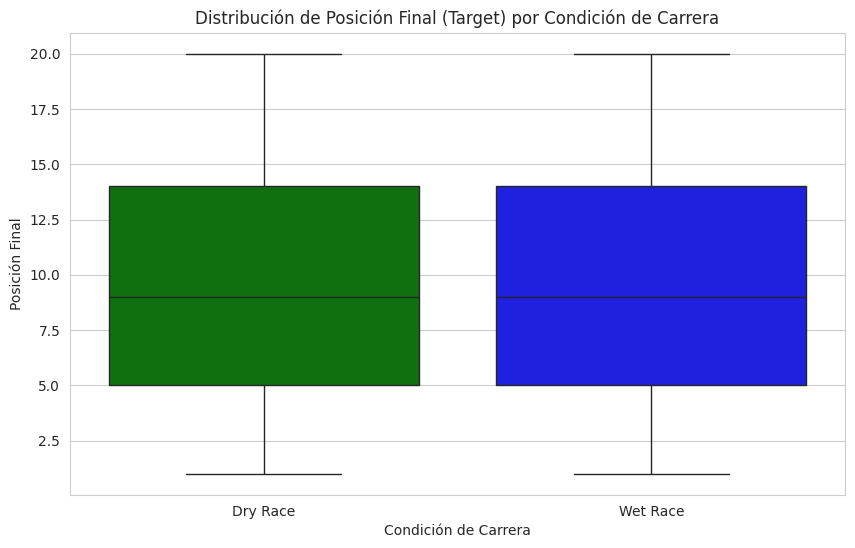

In [37]:
# Comparar la distribución de Posición Final entre Dry y Wet Races
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Race_Condition',
    y='Position_Numeric',
    data=df_clean,
    palette={'Dry Race': 'green', 'Wet Race': 'blue'}
)
plt.title('Distribución de Posición Final (Target) por Condición de Carrera')
plt.xlabel('Condición de Carrera')
plt.ylabel('Posición Final')
plt.show()

C. Análisis del Cambio de Rendimiento (Grid vs. Posición)

/tmp/ipython-input-1613545471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


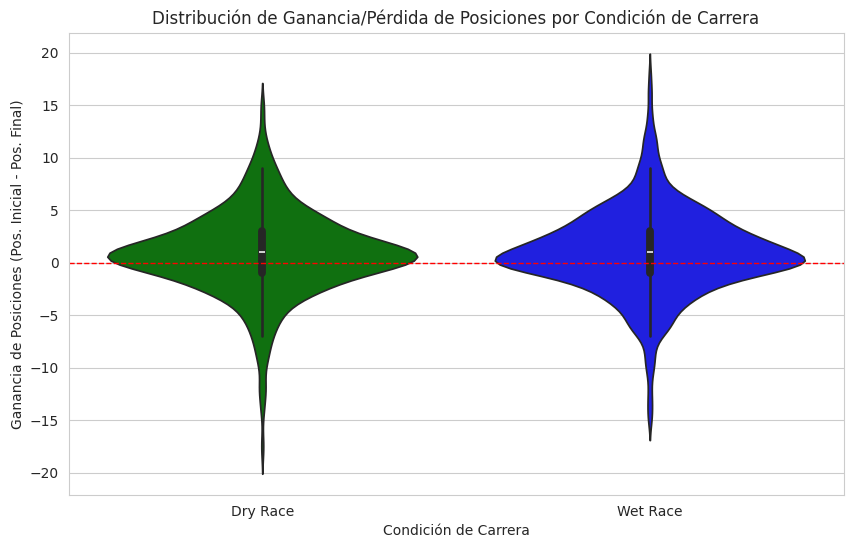

In [38]:
# Medir la diferencia entre la Posición Inicial y la Final
df_clean['Position_Gain_Loss'] = df_clean['Starting Grid'] - df_clean['Position_Numeric']

plt.figure(figsize=(10, 6))
sns.violinplot(
    x='Race_Condition',
    y='Position_Gain_Loss',
    data=df_clean,
    palette={'Dry Race': 'green', 'Wet Race': 'blue'}
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Distribución de Ganancia/Pérdida de Posiciones por Condición de Carrera')
plt.xlabel('Condición de Carrera')
plt.ylabel('Ganancia de Posiciones (Pos. Inicial - Pos. Final)')
plt.show()

# Interpretación: Un valor más alto significa un mejor rendimiento (más posiciones ganadas).
# ¿Muestran las carreras "Wet" una mayor dispersión o un cambio promedio?

In [39]:
correlation_matrix = df_clean.select_dtypes(include=['float64', 'int64']).corr()

In [41]:
print(correlation_matrix['Position_Numeric'].sort_values(ascending=False))

Position_Numeric             1.000000
Starting Grid                0.731842
WEATHER_CODE_MORNING_6H      0.020812
VISIBILITY_AVG_KM            0.017412
WINDTEMP_MAX_C               0.014959
TEMPERATURE_MORNING_C_6H     0.013186
MIN_TEMPERATURE_C            0.012623
season                       0.011759
No                           0.009439
PRESSURE_MAX_MB              0.009374
UV_INDEX                     0.009063
DEWPOINT_MAX_C               0.007570
WINDSPEED_MAX_KMH            0.006593
PRECIP_TOTAL_DAY_MM          0.004516
CLOUDCOVER_AVG_PERCENT       0.004483
TEMPERATURE_NOON_C_12H       0.004174
SUNHOUR                      0.001989
HEATINDEX_MAX_C              0.000606
TEMPERATURE_EVENING_C_18H   -0.000324
MAX_TEMPERATURE_C           -0.000572
HUMIDITY_MAX_PERCENT        -0.005102
WEATHER_CODE_NOON_12H       -0.021113
WEATHER_CODE_EVENING_18H    -0.034824
Laps                        -0.044124
Position_Gain_Loss          -0.234288
Points                      -0.876322
TOTAL_SNOW_M

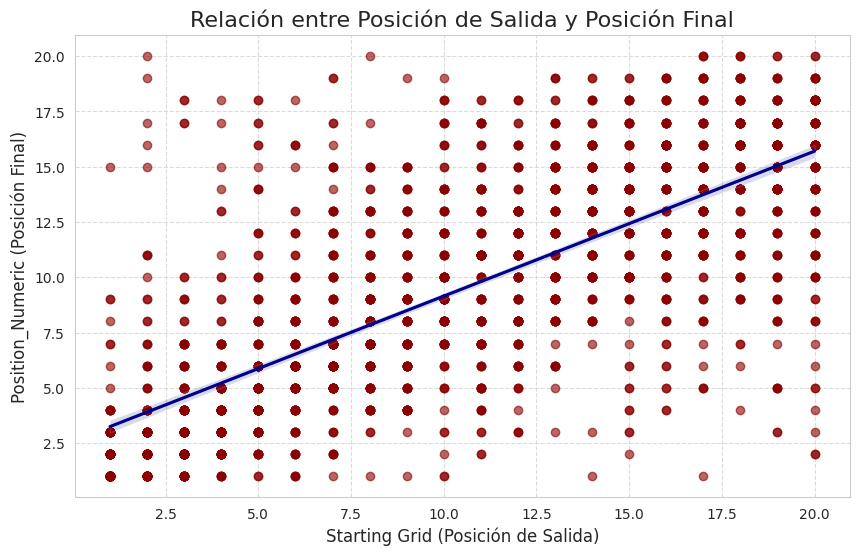

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Gráfico de dispersión con línea de regresión (regplot)
sns.regplot(x='Starting Grid', y='Position_Numeric', data=df_clean,
            scatter_kws={'alpha': 0.6, 'color': 'darkred'},
            line_kws={'color': 'darkblue'})

plt.title('Relación entre Posición de Salida y Posición Final', fontsize=16)
plt.xlabel('Starting Grid (Posición de Salida)', fontsize=12)
plt.ylabel('Position_Numeric (Posición Final)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-3893825097.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Temp_Range', y='Position_Numeric', data=df_clean,


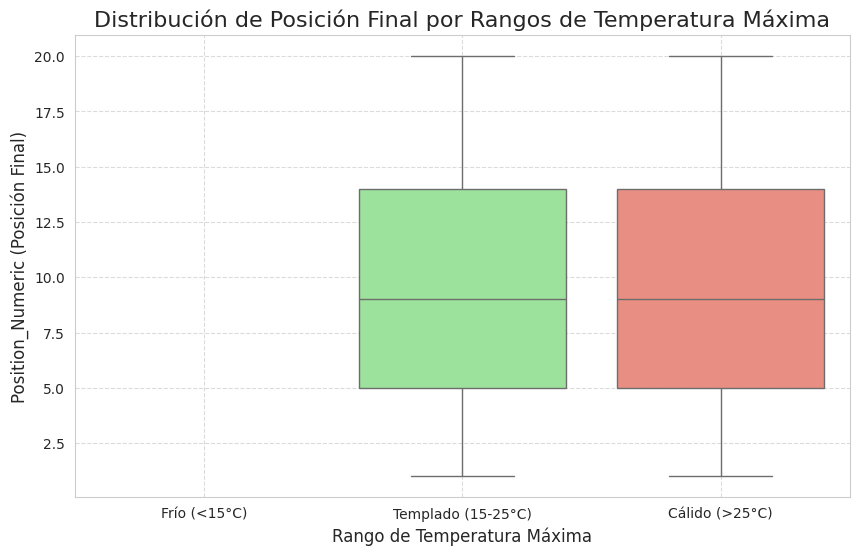

In [43]:
# 1. Definir los límites y etiquetas para las categorías de temperatura
bins = [0, 15, 25, df_clean['MAX_TEMPERATURE_C'].max() + 1]
labels = ['Frío (<15°C)', 'Templado (15-25°C)', 'Cálido (>25°C)']

# 2. Crear la nueva columna categórica
df_clean['Temp_Range'] = pd.cut(df_clean['MAX_TEMPERATURE_C'], bins=bins, labels=labels, right=False)

# 3. Generar el Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Temp_Range', y='Position_Numeric', data=df_clean,
            palette=['skyblue', 'lightgreen', 'salmon'], order=labels)

plt.title('Distribución de Posición Final por Rangos de Temperatura Máxima', fontsize=16)
plt.xlabel('Rango de Temperatura Máxima', fontsize=12)
plt.ylabel('Position_Numeric (Posición Final)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

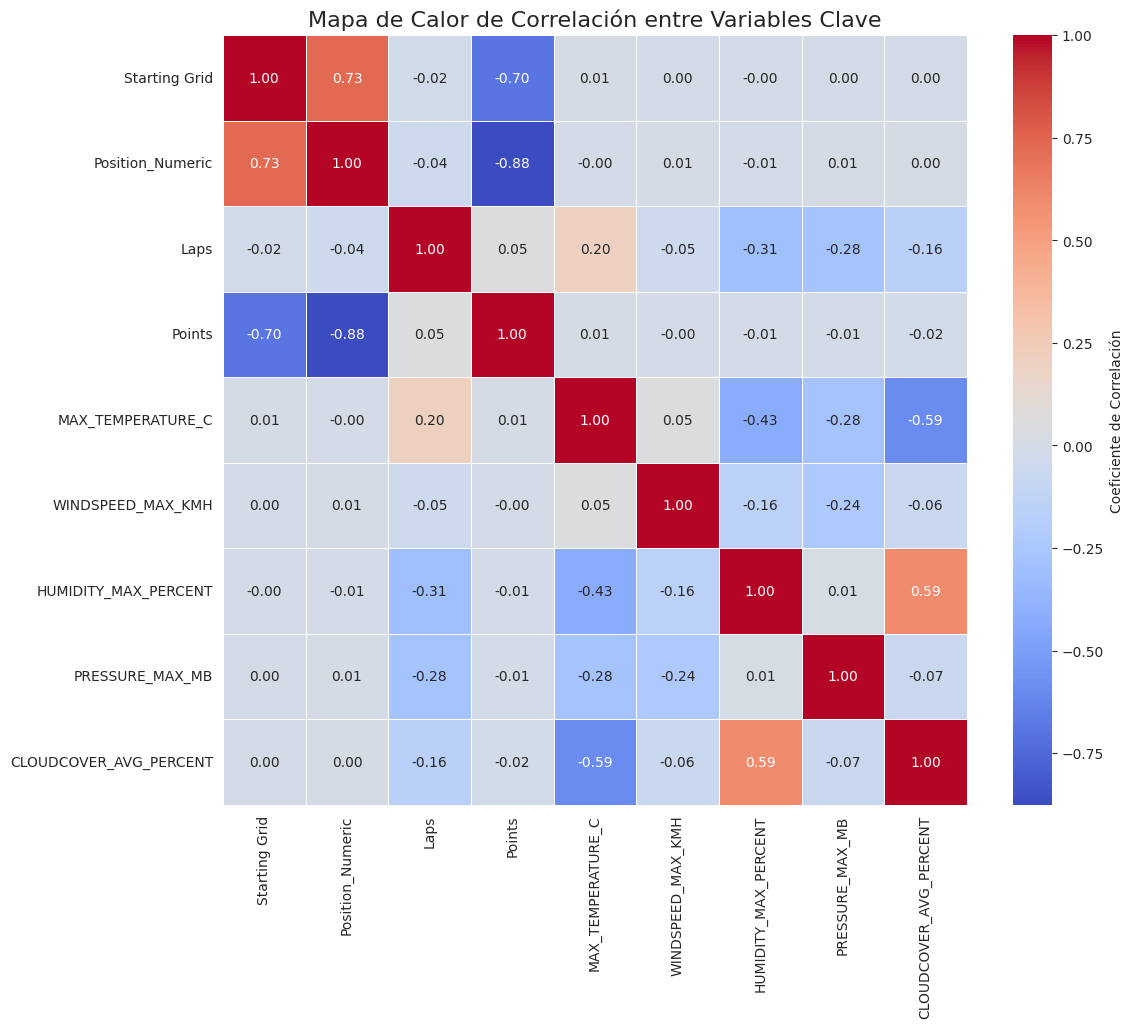

In [44]:
import pandas as pd # Asegurarse de tener pandas importado

# Seleccionar solo variables numéricas que no tienen NaN (o imputar primero)
# Vamos a seleccionar las variables que sabemos que tienen datos y algunas meteorológicas
cols_to_analyze = [
    'Starting Grid', 'Position_Numeric', 'Laps', 'Points',
    'MAX_TEMPERATURE_C', 'WINDSPEED_MAX_KMH', 'HUMIDITY_MAX_PERCENT',
    'PRESSURE_MAX_MB', 'CLOUDCOVER_AVG_PERCENT'
]

# Calcular la matriz de correlación
corr_matrix = df_clean[cols_to_analyze].corr()

plt.figure(figsize=(12, 10))

# Crear el mapa de calor
sns.heatmap(corr_matrix,
            annot=True,          # Mostrar los valores de correlación
            fmt=".2f",           # Formato con dos decimales
            cmap='coolwarm',     # Esquema de color divergente
            linewidths=.5,       # Líneas entre celdas
            cbar_kws={'label': 'Coeficiente de Correlación'})

plt.title('Mapa de Calor de Correlación entre Variables Clave', fontsize=16)
plt.show()

5. PoC 2: Modelado Predictivo (Machine Learning)
Si el análisis descriptivo muestra una relación, el siguiente paso es construir un modelo.

In [45]:
# Importar librerías
import pandas as pd

# Aplicar One-Hot Encoding a la variable 'Track'
df_encoded_tracks = pd.get_dummies(df_clean, columns=['Track'], prefix='Track', dtype=int)

# Mostrar las nuevas columnas
print(df_encoded_tracks.filter(like='Track_').head())

   Track_70th Anniversary  Track_Abu Dhabi  Track_Australia  Track_Austria  \
0                       0                0                1              0   
1                       0                0                1              0   
2                       0                0                1              0   
3                       0                0                1              0   
4                       0                0                1              0   

   Track_Azerbaijan  Track_Bahrain  Track_Belgium  Track_Brazil  Track_Canada  \
0                 0              0              0             0             0   
1                 0              0              0             0             0   
2                 0              0              0             0             0   
3                 0              0              0             0             0   
4                 0              0              0             0             0   

   Track_China  ...  Track_Qatar  Track_Russ

In [46]:
# Importar librerías
from sklearn.model_selection import KFold
import numpy as np

# Definir la variable objetivo
TARGET = 'Position_Numeric'
CATEGORICAL_FEATURES = ['Driver', 'Team']

# Implementación de K-Fold Target Encoding para mitigar el leakage
def target_encode_kfold(df, col, target, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_means = np.zeros(len(df)) # Array para guardar el resultado

    for trn_idx, val_idx in kf.split(df):
        # Calcular el promedio del target solo en el conjunto de entrenamiento (trn_idx)
        mapping = df.iloc[trn_idx].groupby(col)[target].mean()
        # Aplicar el mapping al conjunto de validación (val_idx)
        oof_means[val_idx] = df.iloc[val_idx][col].map(mapping)

    # Imputar los NaN (para categorías que solo aparecen en el conjunto de prueba, si existiera)
    global_mean = df[target].mean()
    df[f'{col}_MeanEnc'] = df[col].map(df.groupby(col)[target].mean()).fillna(global_mean)

    # Usar el out-of-fold para el modelado (la forma más segura)
    return oof_means, df[f'{col}_MeanEnc']

# Aplicar a 'Driver'
df_clean['Driver_MeanEnc_OOF'], df_clean['Driver_MeanEnc'] = target_encode_kfold(df_clean, 'Driver', TARGET)

# Aplicar a 'Team'
df_clean['Team_MeanEnc_OOF'], df_clean['Team_MeanEnc'] = target_encode_kfold(df_clean, 'Team', TARGET)

print("Codificación de Driver y Team finalizada.")

Codificación de Driver y Team finalizada.


In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- A. Codificación One-Hot para 'Track' (si no se hizo antes) ---
# Usamos el DataFrame actual, que ya debe tener las columnas Mean Encoded.
df_final = pd.get_dummies(df_clean, columns=['Track'], prefix='Track', dtype=int)

# --- B. Definición de Variables ---
# 1. Variable Objetivo (y)
y = df_final['Position_Numeric']

# 2. Variables Predictoras (X)
# Usamos las variables Out-of-Fold (OOF) para evitar fuga de datos del Target Encoding.
features = ['Starting Grid', 'Laps', 'Driver_MeanEnc_OOF', 'Team_MeanEnc_OOF']

# Añadir todas las columnas Track_ (generadas por el One-Hot Encoding)
track_cols = [col for col in df_final.columns if col.startswith('Track_')]
features.extend(track_cols)

X = df_final[features]

print(f"Total de Features seleccionadas para el modelo: {len(X.columns)}")

Total de Features seleccionadas para el modelo: 38


In [51]:
# División de los datos: 80% para entrenamiento, 20% para prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para el conjunto de prueba
    random_state=42,     # Fija la semilla para resultados reproducibles
    shuffle=True         # Asegura que la mezcla sea aleatoria
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} registros.")
print(f"Tamaño del conjunto de prueba: {len(X_test)} registros.")

Tamaño del conjunto de entrenamiento: 1794 registros.
Tamaño del conjunto de prueba: 449 registros.


In [52]:
# Calcular métricas de rendimiento
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 40)
print("Resultados de la Evaluación en el Conjunto de Prueba:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print("-" * 40)

# --- C. Interpretación del Modelo (Importancia de Variables) ---
print("\nImportancia de las Variables (Feature Importance):")
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False).head(10))

----------------------------------------
Resultados de la Evaluación en el Conjunto de Prueba:
Error Absoluto Medio (MAE): 2.44
Coeficiente de Determinación (R²): 0.6061
----------------------------------------

Importancia de las Variables (Feature Importance):
Starting Grid         0.507310
Team_MeanEnc_OOF      0.215113
Driver_MeanEnc_OOF    0.083979
Laps                  0.057064
Track_Bahrain         0.011124
Track_Austria         0.007109
Track_Hungary         0.006918
Track_Brazil          0.006804
Track_Azerbaijan      0.006515
Track_Abu Dhabi       0.006425
dtype: float64


In [53]:
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula (grid) de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],  # Número de árboles
    'max_depth': [10, 20, None],      # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],  # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4]     # Mínimo de muestras en una hoja
}

# Inicializar el Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error', # Usamos MAE (negativo, ya que GridSearchCV maximiza la puntuación)
    cv=3,                              # Validación cruzada de 3 pliegues (folds)
    verbose=2,
    n_jobs=-1                          # Usa todos los núcleos
)

# Entrenar la búsqueda en el conjunto de entrenamiento
print("Iniciando Grid Search para optimización de hiperparámetros...")
grid_search.fit(X_train, y_train)

# Mostrar los mejores resultados
print("\n--- Resultados de la Optimización ---")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"Mejor MAE (promedio CV): {-grid_search.best_score_:.3f}")

# Evaluar el mejor modelo en el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"MAE del Modelo Optimizado en el Conjunto de Prueba: {mae_tuned:.3f}")

Iniciando Grid Search para optimización de hiperparámetros...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

--- Resultados de la Optimización ---
Mejores Hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor MAE (promedio CV): 2.339
MAE del Modelo Optimizado en el Conjunto de Prueba: 2.432


# Siguiente Paso: Optimización y Mejora
Aunque el modelo es bueno, te recomiendo ejecutar la Optimización de Hiperparámetros (Hyperparameter Tuning) para intentar exprimir un poco más de rendimiento de tu Random Forest antes de pasar a características más complejas. Esto podría reducir el MAE por algunas décimas.

In [ ]:
# --- Pendiente de Ejecución ---
# 1. Codificar variables categóricas (Driver, Team, Track, Race_Condition)
# 2. Dividir datos en Entrenamiento/Prueba
# 3. Entrenar dos modelos de Regresión (p. ej., Random Forest):
#    - Modelo A (Baseline): Solo variables de control y Starting Grid
#    - Modelo B (Clima): Modelo A + Variables Climáticas
# 4. Comparar el Error Cuadrático Medio (MSE) para demostrar la mejora.